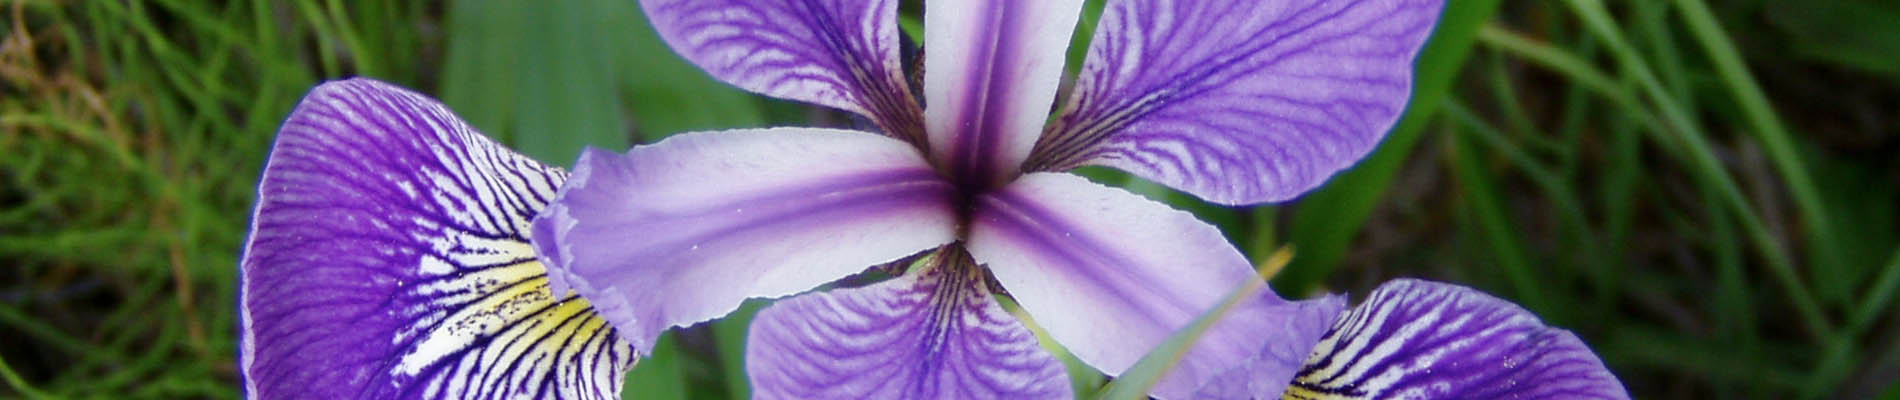

Этот проект посвящён классическому датасету ирисов Фишера и задаче много-классовой классификации. Основная цель — спрогнозировать вид цветка ириса (Setosa, Versicolor или Virginica) на основе четырёх измеряемых признаков:

1) Длина чашелистика (Sepal length)
2) Ширина чашелистика (Sepal width)
3) Длина лепестка (Petal length)
4) Ширина лепестка (Petal width)

Цель проекта — определить вид ириса по его измерениям. Для этого на основе четырёх признаков строятся и обучаются машинные модели, задача которых — точно классифицировать наблюдаемый экземпляр к одному из трёх видов ириса.



In [74]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV


In [75]:
data = pd.read_csv('/content/drive/MyDrive/Iris.csv', index_col='Id')
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica


Просматриваем датасет на наличие пропущенных значений

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [77]:
data.isna().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [78]:
for col in data.columns:
  dif_val = data[col].unique()
  print(f'{col} - {dif_val}')


SepalLengthCm - [5.1 4.9 4.7 4.6 5.  5.4 4.4 4.8 4.3 5.8 5.7 5.2 5.5 4.5 5.3 7.  6.4 6.9
 6.5 6.3 6.6 5.9 6.  6.1 5.6 6.7 6.2 6.8 7.1 7.6 7.3 7.2 7.7 7.4 7.9]
SepalWidthCm - [3.5 3.  3.2 3.1 3.6 3.9 3.4 2.9 3.7 4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8 2.4
 2.7 2.  2.2 2.5 2.6]
PetalLengthCm - [1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.8 6.6 6.3 6.1 5.3
 5.5 6.7 6.9 5.7 6.4 5.4 5.2]
PetalWidthCm - [0.2 0.4 0.3 0.1 0.5 0.6 1.4 1.5 1.3 1.6 1.  1.1 1.8 1.2 1.7 2.5 1.9 2.1
 2.2 2.  2.4 2.3]
Species - ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


Для удобства составлю списки с именами разных колонок

In [79]:
num_cols = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

target_col = 'Species'

Выполняем небольшой анализ данных: посмотрю распределение наших признаков

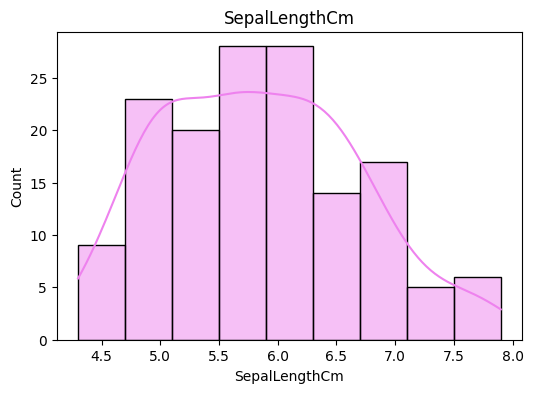

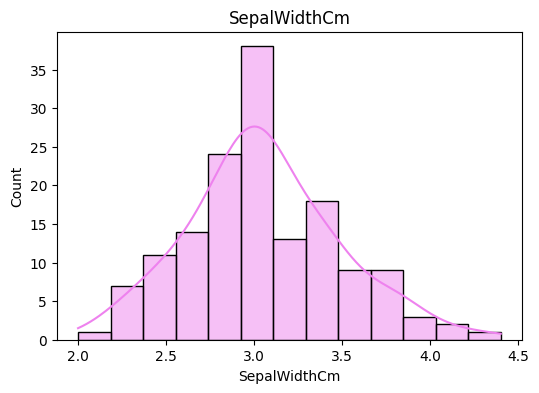

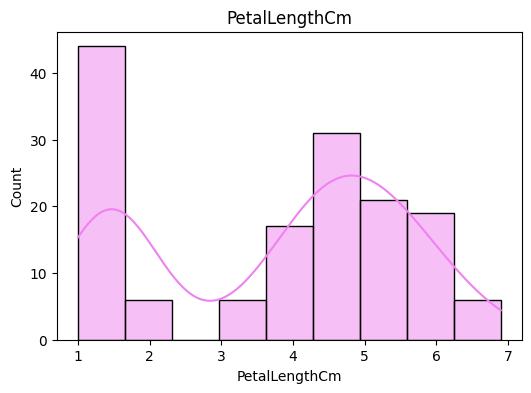

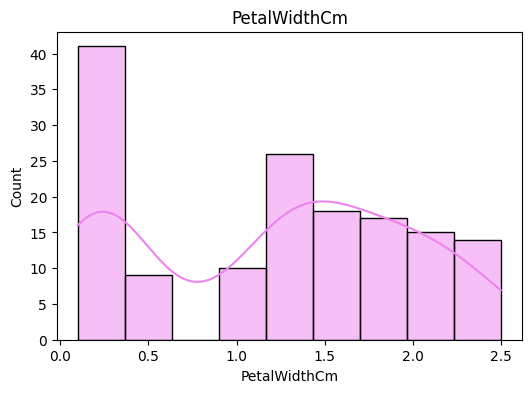

In [80]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(data[col], kde=True, color='violet')
  plt.title(col)
  plt.show()
  print('\n')


Проанализируем целевую переменную

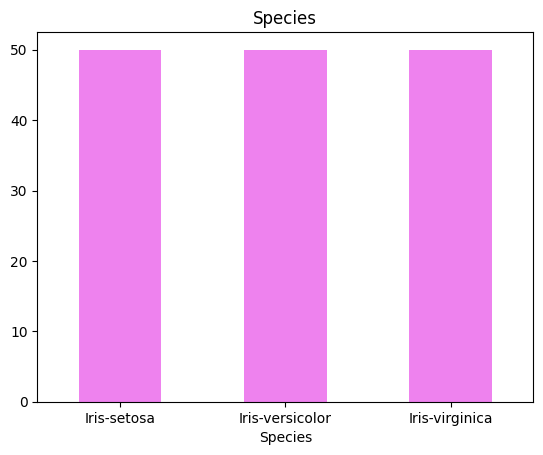

In [81]:
data[target_col].value_counts().plot(kind='bar', color='violet')
plt.xticks(rotation=0)
plt.title(target_col)
plt.show()

Применяем LabelEncoder к целевой переменной

In [82]:
label_encoding = LabelEncoder()
data[target_col] = label_encoding.fit_transform(data[target_col])
data[target_col].value_counts()

,count
Species,
0,50
1,50
2,50


Разделяем датасет на обучающуюся и тестовую выборку

In [83]:
X_train, X_test, y_train, y_test = train_test_split(data[num_cols], data[target_col], train_size=0.2, random_state=42)

Используем GridSearchCV, которая используется для поиска наилучших гиперпараметров, и обучаем модель

In [84]:
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 4, 6, None],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5, # 5-кратная кроссвалидация
    scoring='accuracy', # метрика
    n_jobs=-1,
    verbose=1
    )

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print('Лучшие параметры:', grid_search.best_params_)
print('Лучшая accuracy:', grid_search.best_score_)
print('Лучшая модель:', best_model)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}
Лучшая accuracy: 0.9666666666666668
Лучшая модель: RandomForestClassifier(max_depth=2, n_estimators=50, random_state=42)


In [85]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test_encoded, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9333333333333333


In [86]:
import joblib
joblib.dump(best_model, 'iris_model.pkl')

['iris_model.pkl']